# ORACLE — MedQuAD EDA
## Patient-Facing Health Information Domain

**Dataset:** MedQuAD — 47,441 medical QA pairs from 12 NIH websites (Ben Abacha & Demner-Fushman, 2019)
**Key finding:** 65.4% of records have no answer — structural missingness, not random
**RAG-usable subset:** 16,407 records (34.6%) from 8 full-coverage sources
**Purpose:** ORACLE patient-facing health information accessibility evaluation

In [1]:
import sys
import os
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datasets import load_dataset

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
os.makedirs('../figures/eda', exist_ok=True)

FULL_SOURCES = ['CDC','CancerGov','GHR','MPlusHealthTopics','NHLBI','NIDDK','NIHSeniorHealth','NINDS']
NONE_SOURCES = ['ADAM','MPlusDrugs','MPlusHerbsSupplements']
SOURCE_ORDER = NONE_SOURCES + ['GARD'] + FULL_SOURCES
print('Imports complete')

Imports complete


In [2]:
dataset = load_dataset('lavita/MedQuAD')
df = dataset['train'].to_pandas()

df['has_answer'] = df['answer'].notna()
df['q_len'] = df['question'].astype(str).str.len()
df_ans = df[df['has_answer']].copy()
df_ans['ans_len'] = df_ans['answer'].astype(str).str.len()

print(f'Shape: {df.shape}')
print(f'Total records: {len(df):,}')
print(f'With answers: {df["has_answer"].sum():,} ({df["has_answer"].mean():.1%})')
print(f'Without answers: {(~df["has_answer"]).sum():,} ({(~df["has_answer"]).mean():.1%})')
print(f'RAG-usable: {df["has_answer"].sum():,} records')

Shape: (47441, 15)
Total records: 47,441
With answers: 16,407 (34.6%)
Without answers: 31,034 (65.4%)
RAG-usable: 16,407 records


## 1. Answer Coverage by Source — Structural Missingness

ADAM (17,348) + MPlusDrugs (12,889) + MPlusHerbsSupplements (792) = 31,029 records with zero answers.
This is structural — entire sources have no answers, not random missingness.

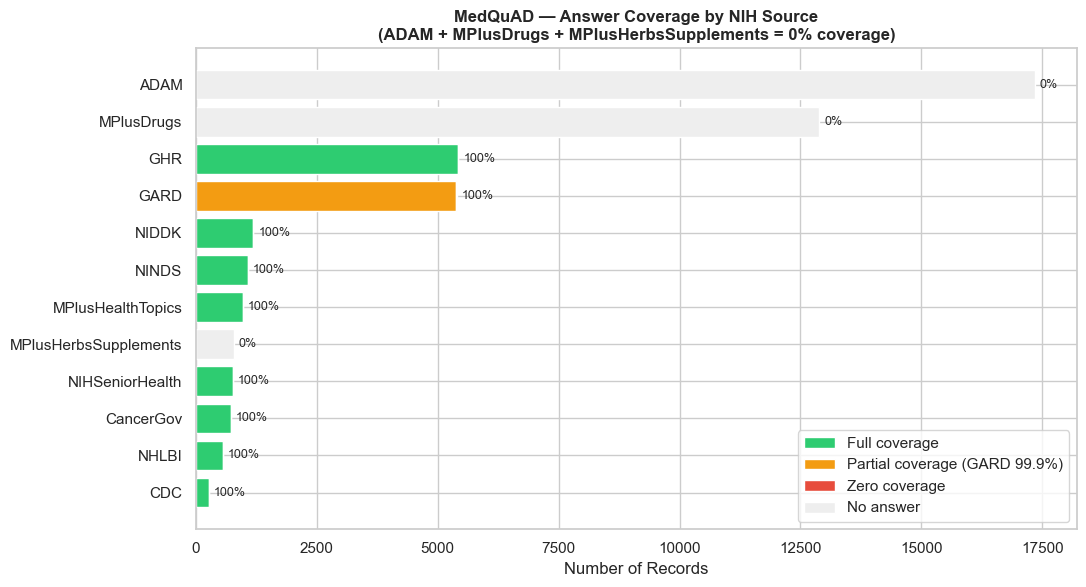

Fig 1 saved — medquad_coverage_by_source.png


In [3]:
coverage = df.groupby('document_source')['has_answer'].agg(['sum','count']).reset_index()
coverage.columns = ['source','with_answer','total']
coverage['without'] = coverage['total'] - coverage['with_answer']
coverage['pct'] = coverage['with_answer'] / coverage['total']
coverage = coverage.sort_values('total', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
colors_has = ['#2ecc71' if s in FULL_SOURCES else '#e74c3c' if s in NONE_SOURCES else '#f39c12'
              for s in coverage['source']]
ax.barh(coverage['source'], coverage['with_answer'], color=colors_has, label='Has answer')
ax.barh(coverage['source'], coverage['without'],
        left=coverage['with_answer'], color='#eeeeee', label='No answer', edgecolor='white')

for i, (_, row) in enumerate(coverage.iterrows()):
    ax.text(row['total'] + 100, i, f"{row['pct']:.0%}", va='center', fontsize=9)

ax.set_title('MedQuAD — Answer Coverage by NIH Source\n(ADAM + MPlusDrugs + MPlusHerbsSupplements = 0% coverage)', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Records')
legend_elements = [mpatches.Patch(facecolor='#2ecc71', label='Full coverage'),
                   mpatches.Patch(facecolor='#f39c12', label='Partial coverage (GARD 99.9%)'),
                   mpatches.Patch(facecolor='#e74c3c', label='Zero coverage'),
                   mpatches.Patch(facecolor='#eeeeee', label='No answer')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('../figures/eda/medquad_coverage_by_source.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 1 saved — medquad_coverage_by_source.png')

## 2. RAG-Usable vs Unusable — Structural Split

16,407 records usable for RAG evaluation (34.6%). 31,034 structurally missing answers.

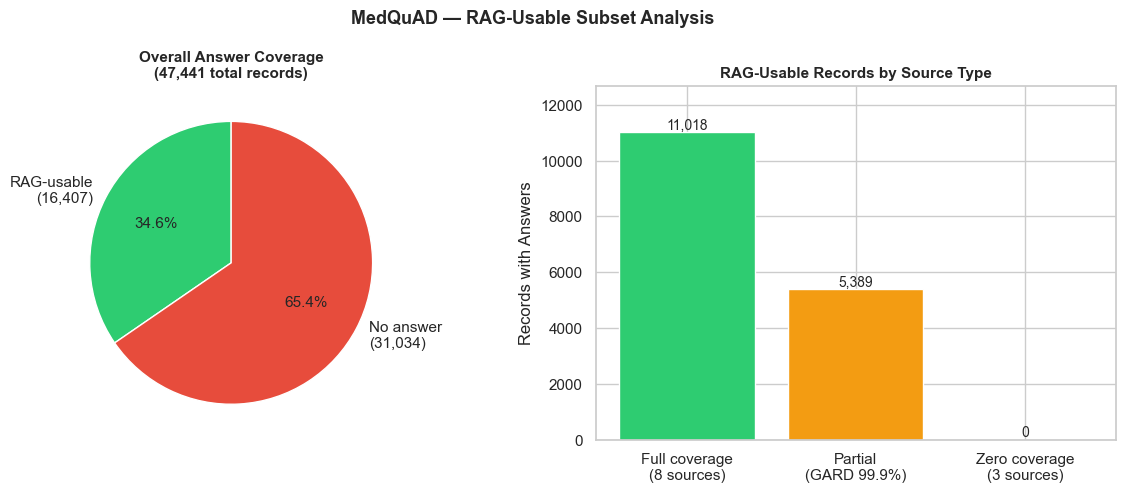

Fig 2 saved — medquad_rag_usable.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['RAG-usable\n(16,407)', 'No answer\n(31,034)']
sizes = [df['has_answer'].sum(), (~df['has_answer']).sum()]
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Overall Answer Coverage\n(47,441 total records)', fontsize=11, fontweight='bold')

source_types = {'Full coverage\n(8 sources)': df[df['document_source'].isin(FULL_SOURCES)]['has_answer'].sum(),
                'Partial\n(GARD 99.9%)': df[df['document_source']=='GARD']['has_answer'].sum(),
                'Zero coverage\n(3 sources)': 0}
bars = axes[1].bar(list(source_types.keys()), list(source_types.values()),
                   color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='white')
for bar, val in zip(bars, source_types.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontsize=10)
axes[1].set_title('RAG-Usable Records by Source Type', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Records with Answers')
axes[1].set_ylim(0, max(source_types.values()) * 1.15)

plt.suptitle('MedQuAD — RAG-Usable Subset Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/medquad_rag_usable.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 2 saved — medquad_rag_usable.png')

## 3. Answer Coverage by Category — Drug Category Has Zero Coverage

UMLS metadata presence inversely correlated with answer availability.
NaN category (no UMLS metadata) = 100% answer coverage.

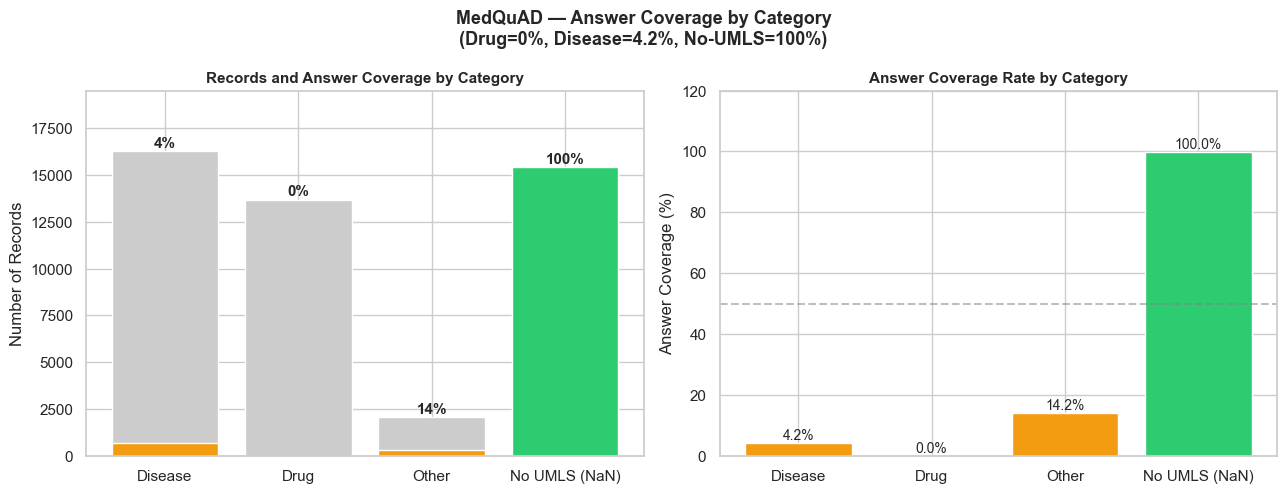

Fig 3 saved — medquad_coverage_by_category.png


In [5]:
cat_data = df.groupby('category', dropna=False)['has_answer'].agg(['sum','count']).reset_index()
cat_data.columns = ['category','with_answer','total']
cat_data['without'] = cat_data['total'] - cat_data['with_answer']
cat_data['pct'] = cat_data['with_answer'] / cat_data['total']
cat_data['category'] = cat_data['category'].fillna('No UMLS (NaN)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#2ecc71' if p > 0.5 else '#e74c3c' if p == 0 else '#f39c12'
          for p in cat_data['pct']]
axes[0].bar(cat_data['category'], cat_data['total'], color='#cccccc', edgecolor='white', label='Total')
axes[0].bar(cat_data['category'], cat_data['with_answer'], color=colors, edgecolor='white', label='With answer')
for i, (_, row) in enumerate(cat_data.iterrows()):
    axes[0].text(i, row['total'] + 200, f"{row['pct']:.0%}", ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Records and Answer Coverage by Category', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Records')
axes[0].set_ylim(0, cat_data['total'].max() * 1.2)

axes[1].bar(cat_data['category'], cat_data['pct'] * 100, color=colors, edgecolor='white')
axes[1].axhline(50, color='gray', linestyle='--', alpha=0.5)
for i, (_, row) in enumerate(cat_data.iterrows()):
    axes[1].text(i, row['pct']*100 + 1, f"{row['pct']:.1%}", ha='center', fontsize=10)
axes[1].set_title('Answer Coverage Rate by Category', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Answer Coverage (%)')
axes[1].set_ylim(0, 120)

plt.suptitle('MedQuAD — Answer Coverage by Category\n(Drug=0%, Disease=4.2%, No-UMLS=100%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/medquad_coverage_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 3 saved — medquad_coverage_by_category.png')

## 4. Question Type Distribution — Top 15

39 unique question types — most granular taxonomy across all ORACLE datasets.
'information' dominates (9,214) but only 49.2% answer coverage.

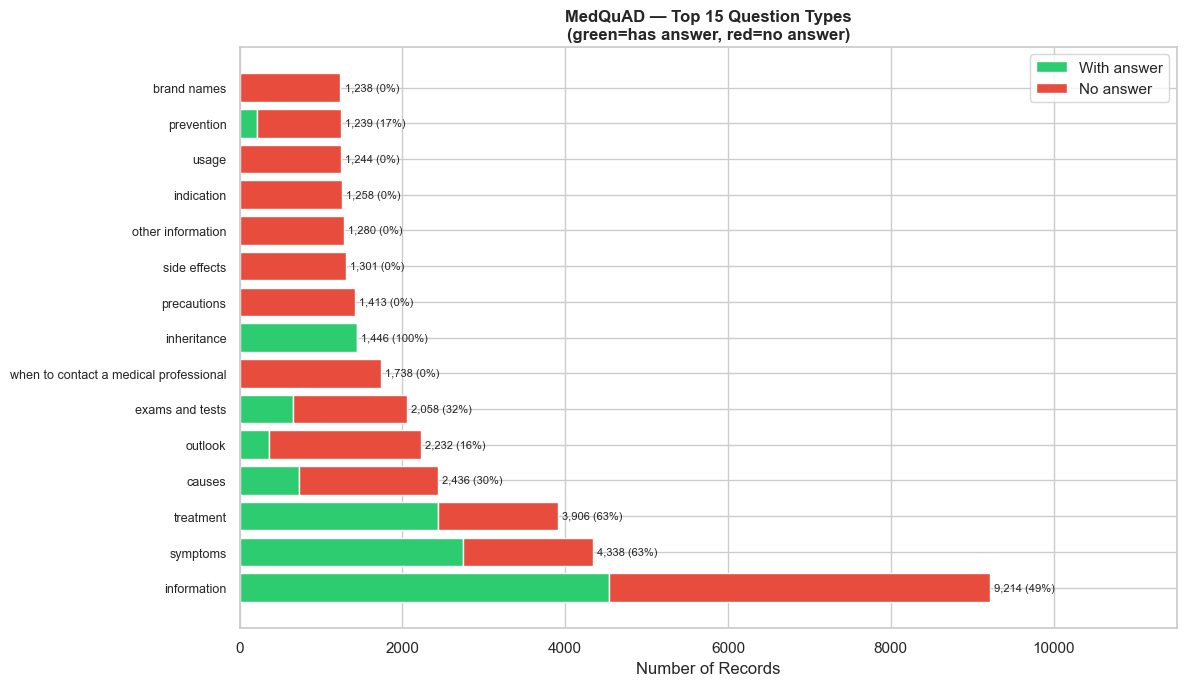

Fig 4 saved — medquad_question_type_dist.png


In [6]:
qt_counts = df['question_type'].value_counts().head(15)
qt_with = [df[df['question_type']==qt]['has_answer'].sum() for qt in qt_counts.index]
qt_without = [qt_counts[qt] - w for qt, w in zip(qt_counts.index, qt_with)]

fig, ax = plt.subplots(figsize=(12, 7))
y = range(len(qt_counts))
ax.barh(list(y), qt_with, color='#2ecc71', label='With answer', edgecolor='white')
ax.barh(list(y), qt_without, left=qt_with, color='#e74c3c', label='No answer', edgecolor='white')
ax.set_yticks(list(y))
ax.set_yticklabels(qt_counts.index, fontsize=9)
for i, (qt, total, w) in enumerate(zip(qt_counts.index, qt_counts.values, qt_with)):
    ax.text(total + 50, i, f'{total:,} ({w/total:.0%})', va='center', fontsize=8)
ax.set_title('MedQuAD — Top 15 Question Types\n(green=has answer, red=no answer)', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Records')
ax.legend()
ax.set_xlim(0, qt_counts.max() * 1.25)
plt.tight_layout()
plt.savefig('../figures/eda/medquad_question_type_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 4 saved — medquad_question_type_dist.png')

## 5. Answer Coverage by Question Type — Top 10 by Coverage Rate

Inheritance, genetic changes, frequency = 100% coverage.
Clinical question types (symptoms, treatment) = 62-63% coverage.

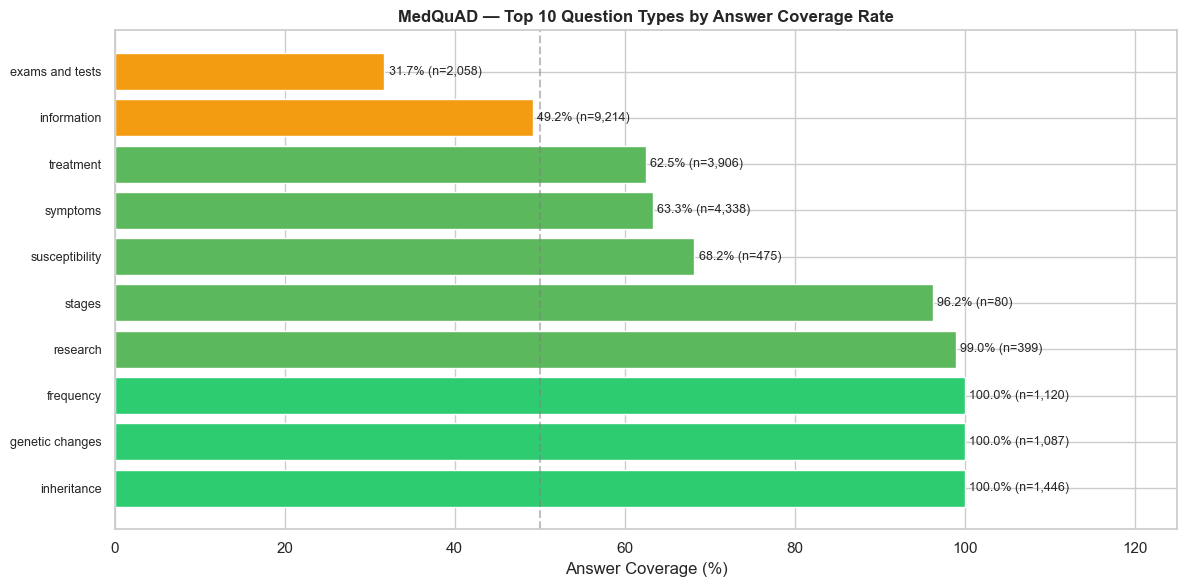

Fig 5 saved — medquad_coverage_by_qtype.png


In [7]:
qt_coverage = df.groupby('question_type').apply(
    lambda x: x['has_answer'].mean()).sort_values(ascending=False).head(10)
qt_totals = [df[df['question_type']==qt].shape[0] for qt in qt_coverage.index]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ecc71' if p == 1.0 else '#5cb85c' if p > 0.5 else '#f39c12'
          for p in qt_coverage.values]
ax.barh(range(len(qt_coverage)), qt_coverage.values * 100, color=colors, edgecolor='white')
ax.set_yticks(range(len(qt_coverage)))
ax.set_yticklabels(qt_coverage.index, fontsize=9)
for i, (qt, pct, total) in enumerate(zip(qt_coverage.index, qt_coverage.values, qt_totals)):
    ax.text(pct*100 + 0.5, i, f'{pct:.1%} (n={total:,})', va='center', fontsize=9)
ax.axvline(50, color='gray', linestyle='--', alpha=0.5)
ax.set_title('MedQuAD — Top 10 Question Types by Answer Coverage Rate', fontsize=12, fontweight='bold')
ax.set_xlabel('Answer Coverage (%)')
ax.set_xlim(0, 125)
plt.tight_layout()
plt.savefig('../figures/eda/medquad_coverage_by_qtype.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 5 saved — medquad_coverage_by_qtype.png')

## 6. Question Length by Source — MPlusDrugs Longest Questions

Overall mean 52 chars — shortest across all ORACLE datasets.
Patient-facing questions are concise and direct.

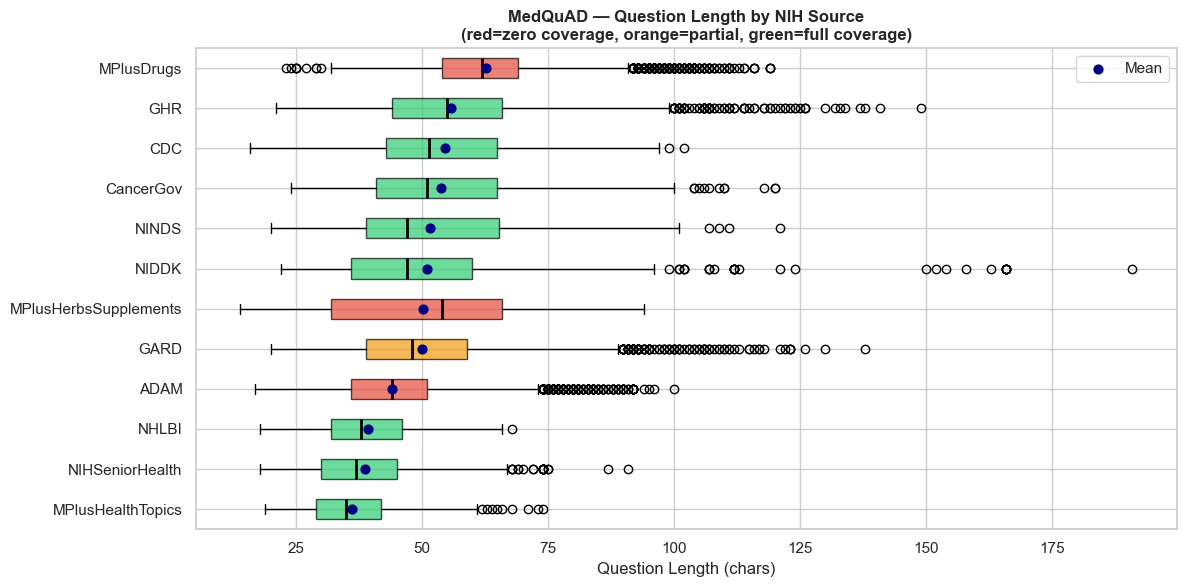

Fig 6 saved — medquad_question_length.png


In [8]:
src_order_by_len = df.groupby('document_source')['q_len'].mean().sort_values().index.tolist()
data_by_src = [df[df['document_source']==src]['q_len'].values for src in src_order_by_len]
colors_src = ['#e74c3c' if s in NONE_SOURCES else '#f39c12' if s == 'GARD' else '#2ecc71'
              for s in src_order_by_len]

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(data_by_src, labels=src_order_by_len, patch_artist=True, vert=False,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_src):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
means = [df[df['document_source']==src]['q_len'].mean() for src in src_order_by_len]
ax.scatter(means, range(1, len(src_order_by_len)+1), color='navy', zorder=5, s=40, label='Mean')
ax.set_title('MedQuAD — Question Length by NIH Source\n(red=zero coverage, orange=partial, green=full coverage)', fontsize=12, fontweight='bold')
ax.set_xlabel('Question Length (chars)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/medquad_question_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 6 saved — medquad_question_length.png')

## 7. Answer Length Distribution — Long Narrative Answers

Mean 1,303 chars, median 890 — 25x longer than questions (mean 52).
ORACLE chunking strategy must handle long narrative patient-facing answers.

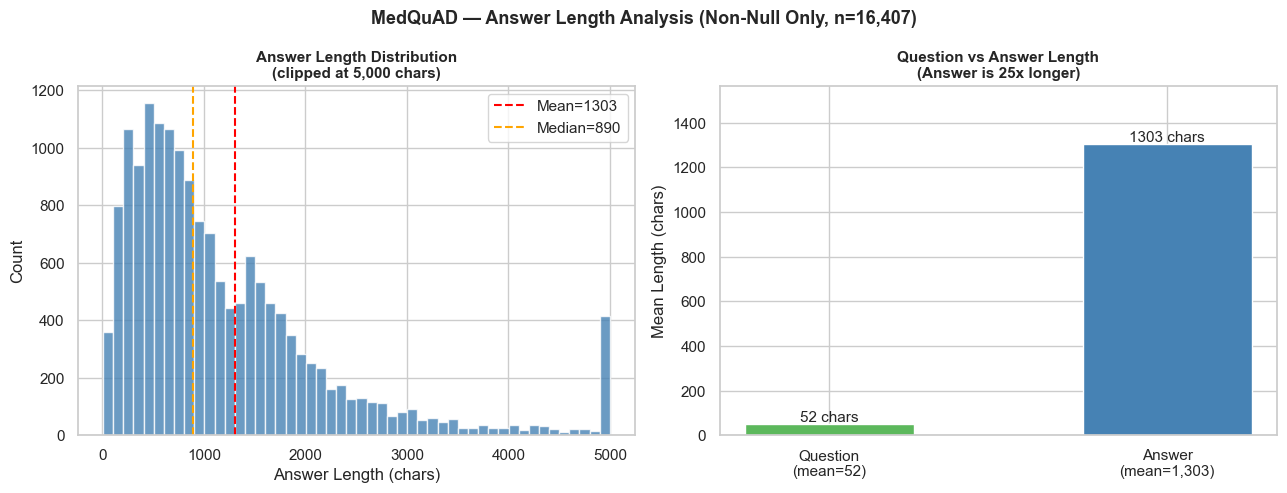

Fig 7 saved — medquad_answer_length.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df_ans['ans_len'].clip(upper=5000), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df_ans['ans_len'].mean(), color='red', linestyle='--',
                label=f'Mean={df_ans["ans_len"].mean():.0f}')
axes[0].axvline(df_ans['ans_len'].median(), color='orange', linestyle='--',
                label=f'Median={df_ans["ans_len"].median():.0f}')
axes[0].set_title('Answer Length Distribution\n(clipped at 5,000 chars)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Answer Length (chars)')
axes[0].set_ylabel('Count')
axes[0].legend()

qa_means = {'Question\n(mean=52)': df['q_len'].mean(),
            'Answer\n(mean=1,303)': df_ans['ans_len'].mean()}
bars = axes[1].bar(list(qa_means.keys()), list(qa_means.values()),
                   color=['#5cb85c','steelblue'], edgecolor='white', width=0.5)
for bar, val in zip(bars, qa_means.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:.0f} chars', ha='center', fontsize=11)
axes[1].set_title(f'Question vs Answer Length\n(Answer is {df_ans["ans_len"].mean()/df["q_len"].mean():.0f}x longer)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Mean Length (chars)')
axes[1].set_ylim(0, df_ans['ans_len'].mean() * 1.2)

plt.suptitle('MedQuAD — Answer Length Analysis (Non-Null Only, n=16,407)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/medquad_answer_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 7 saved — medquad_answer_length.png')

## 8. Top Question Focus Areas — Cancer and Chronic Disease Dominant

Breast Cancer (53), Stroke (44), Prostate Cancer (43) most frequent.
Reflects NIH health priority areas.

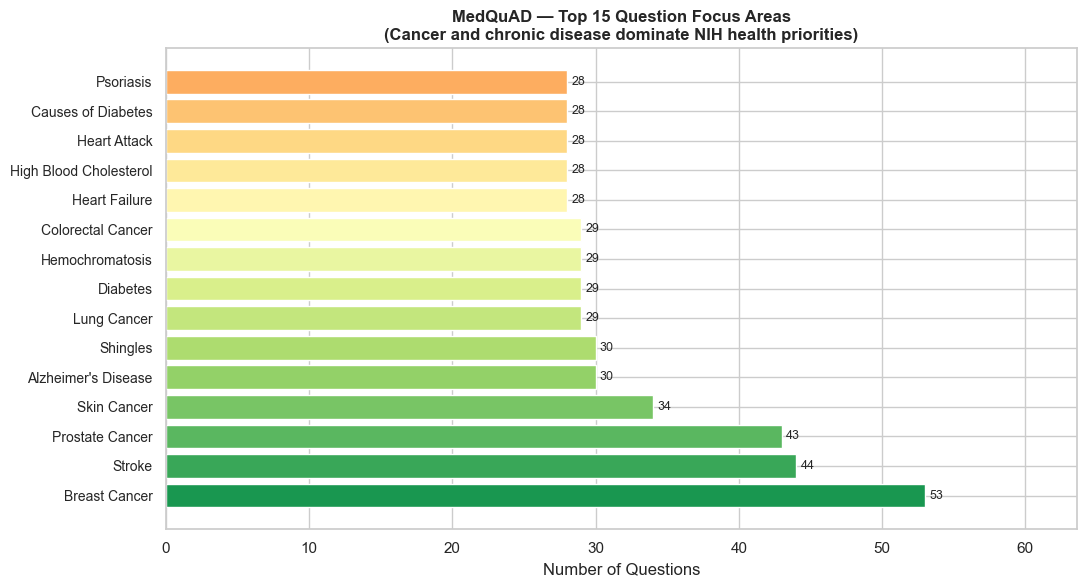

Fig 8 saved — medquad_question_focus.png


In [10]:
top_focus = df['question_focus'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_focus)))[::-1]
bars = ax.barh(range(len(top_focus)), top_focus.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(top_focus)))
ax.set_yticklabels(top_focus.index, fontsize=10)
for bar, val in zip(bars, top_focus.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_title('MedQuAD — Top 15 Question Focus Areas\n(Cancer and chronic disease dominate NIH health priorities)', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Questions')
ax.set_xlim(0, top_focus.max() * 1.2)
plt.tight_layout()
plt.savefig('../figures/eda/medquad_question_focus.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 8 saved — medquad_question_focus.png')

## 9b. Answer Length by Source — CancerGov 6x Longer than NINDS

CancerGov (mean=3,881) vs NINDS (mean=655) — 6x difference.
Directly affects ORACLE chunking strategy per source.

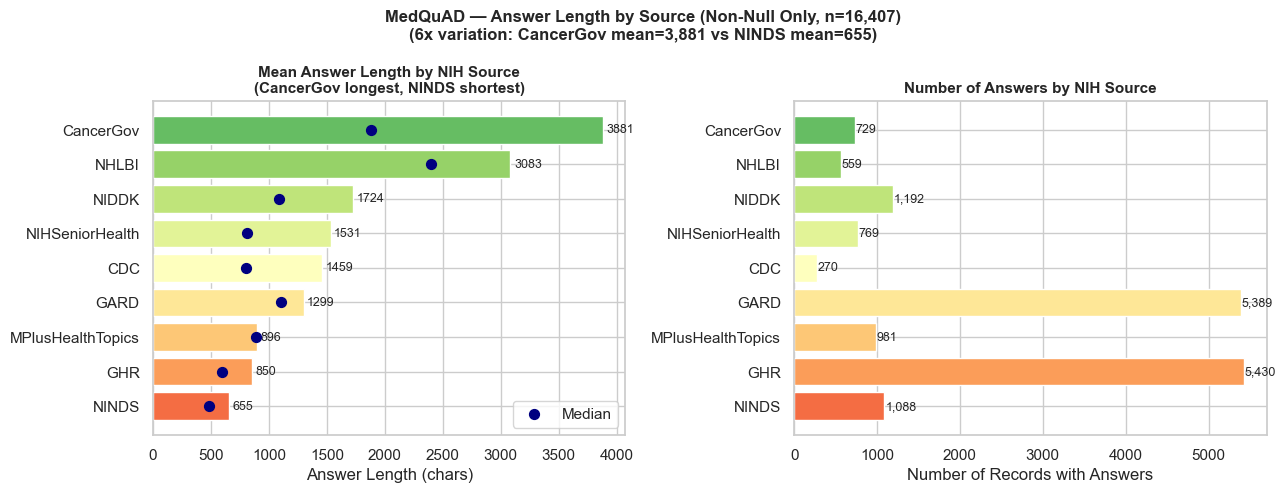

Fig 9b saved — medquad_answer_length_by_source.png


In [11]:
src_ans_stats = df_ans.groupby('document_source')['ans_len'].agg(['mean','median','count']).reset_index()
src_ans_stats.columns = ['source','mean','median','count']
src_ans_stats = src_ans_stats.sort_values('mean', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(src_ans_stats)))
bars = axes[0].barh(src_ans_stats['source'], src_ans_stats['mean'],
                    color=colors, edgecolor='white')
axes[0].scatter(src_ans_stats['median'], range(len(src_ans_stats)),
                color='navy', zorder=5, s=50, label='Median')
for i, (_, row) in enumerate(src_ans_stats.iterrows()):
    axes[0].text(row['mean'] + 30, i, f"{row['mean']:.0f}", va='center', fontsize=9)
axes[0].set_title('Mean Answer Length by NIH Source\n(CancerGov longest, NINDS shortest)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Answer Length (chars)')
axes[0].legend()

axes[1].barh(src_ans_stats['source'], src_ans_stats['count'],
             color=colors, edgecolor='white')
for i, (_, row) in enumerate(src_ans_stats.iterrows()):
    axes[1].text(row['count'] + 10, i, f"{row['count']:,}", va='center', fontsize=9)
axes[1].set_title('Number of Answers by NIH Source', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Number of Records with Answers')

plt.suptitle('MedQuAD — Answer Length by Source (Non-Null Only, n=16,407)\n(6x variation: CancerGov mean=3,881 vs NINDS mean=655)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/medquad_answer_length_by_source.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 9b saved — medquad_answer_length_by_source.png')

## 9. Missing Values Profile — Answer Dominates (65.4%)

Structural missingness: answer (65.4%), category (32.5%), UMLS fields (~33.8%).
question, question_type, document_source are complete.

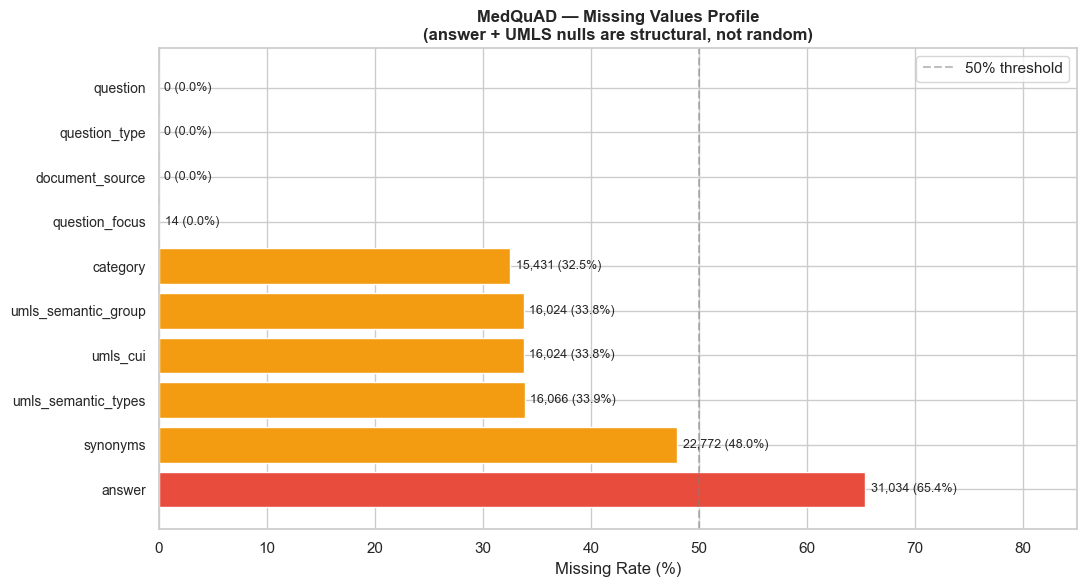

Fig 9 saved — medquad_missing_values.png


In [12]:
key_cols = ['document_source','category','question_type','question',
            'answer','question_focus','umls_cui','umls_semantic_types','umls_semantic_group','synonyms']
null_rates = [(col, df[col].isnull().sum(), df[col].isnull().mean()*100) for col in key_cols]
null_rates.sort(key=lambda x: x[2], reverse=True)
cols, nulls, pcts = zip(*null_rates)
colors = ['#e74c3c' if p > 50 else '#f39c12' if p > 10 else '#2ecc71' for p in pcts]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(range(len(cols)), pcts, color=colors, edgecolor='white')
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=10)
for i, (null, pct) in enumerate(zip(nulls, pcts)):
    ax.text(pct + 0.5, i, f'{null:,} ({pct:.1f}%)', va='center', fontsize=9)
ax.axvline(50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
ax.set_title('MedQuAD — Missing Values Profile\n(answer + UMLS nulls are structural, not random)', fontsize=12, fontweight='bold')
ax.set_xlabel('Missing Rate (%)')
ax.set_xlim(0, 85)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/medquad_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 9 saved — medquad_missing_values.png')

## 10. MedQuAD vs Other ORACLE Datasets — Scale and Usability

MedQuAD has most records (47,441) but lowest usable rate (34.6%).
Only ORACLE dataset testing patient-facing lay language retrieval.

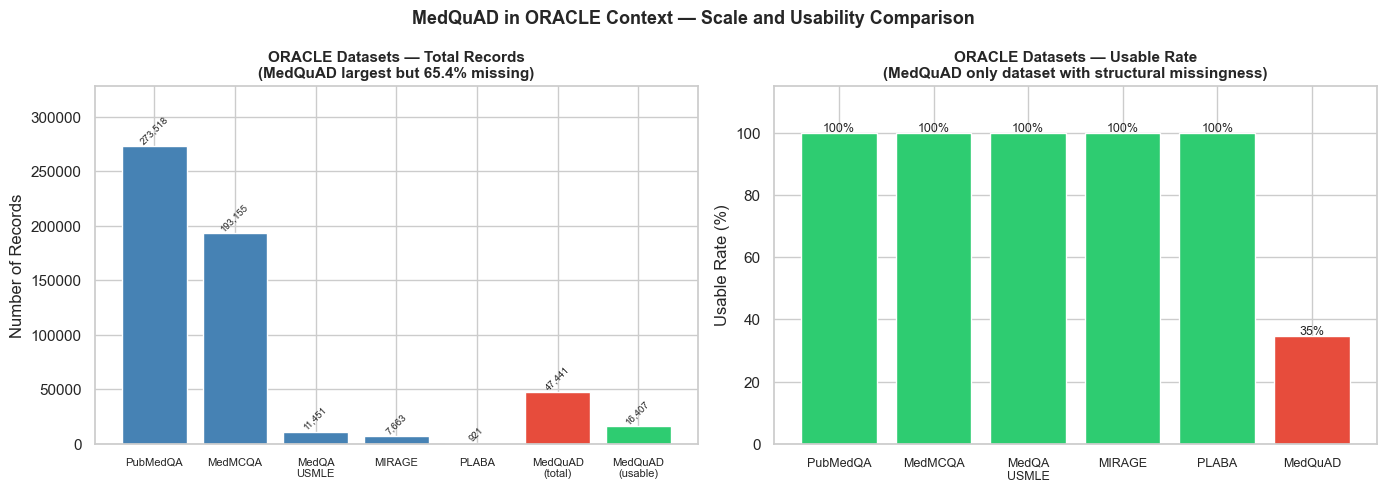

Fig 10 saved — medquad_oracle_comparison.png


In [13]:
datasets_all = ['PubMedQA','MedMCQA','MedQA\nUSMLE','MIRAGE','PLABA','MedQuAD\n(total)','MedQuAD\n(usable)']
totals_all = [273518, 193155, 11451, 7663, 921, 47441, 16407]
bar_colors = ['steelblue','steelblue','steelblue','steelblue','steelblue','#e74c3c','#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(datasets_all, totals_all, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, totals_all):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{val:,}', ha='center', fontsize=7, rotation=45)
axes[0].set_title('ORACLE Datasets — Total Records\n(MedQuAD largest but 65.4% missing)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Records')
axes[0].set_ylim(0, max(totals_all) * 1.2)
axes[0].tick_params(axis='x', labelsize=8)

ds_names = ['PubMedQA','MedMCQA','MedQA\nUSMLE','MIRAGE','PLABA','MedQuAD']
usable_pcts = [100, 100, 100, 100, 100, 34.6]
bar_colors2 = ['#2ecc71' if p == 100 else '#e74c3c' for p in usable_pcts]
bars2 = axes[1].bar(ds_names, usable_pcts, color=bar_colors2, edgecolor='white')
for bar, val in zip(bars2, usable_pcts):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.0f}%', ha='center', fontsize=9)
axes[1].set_title('ORACLE Datasets — Usable Rate\n(MedQuAD only dataset with structural missingness)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Usable Rate (%)')
axes[1].set_ylim(0, 115)
axes[1].tick_params(axis='x', labelsize=9)

plt.suptitle('MedQuAD in ORACLE Context — Scale and Usability Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/medquad_oracle_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 10 saved — medquad_oracle_comparison.png')

## 11. Key Observations

**Scale:** 47,441 records across 12 NIH sources — largest ORACLE dataset by record count
**Critical finding:** 65.4% structural missingness — ADAM (17,348) + MPlusDrugs (12,889) + MPlusHerbsSupplements (792) + 5 GARD = 31,034 total missing
**RAG-usable subset:** 16,407 records (34.6%) from 8 full-coverage NIH sources
**Category paradox:** Drug=0%, Disease=4.2%, No-UMLS=100% — UMLS metadata inversely correlated with answer availability
**Question types:** 39 unique types — inheritance/genetic changes/frequency = 100% coverage; symptoms/treatment = 62-63%
**Answer length:** Mean 1,303 chars — 25x longer than questions (mean 52) — ORACLE chunking must handle long narratives
**Focus areas:** Breast Cancer, Stroke, Prostate Cancer dominate — reflects NIH chronic disease priorities
**ORACLE role:** Only dataset testing patient-facing lay language retrieval — core to ORACLE accessibility research question